# Path Tracing Notebook
Implementation of Light Transport Algorithms

********************************************************************************************

In [1]:
import os
os.chdir("..")
print(os.getcwd())

/Volumes/Work/Projects/Rendering/light-transport-simulator


In [2]:
import taichi as ti
ti.init(arch=ti.cpu, debug=True, random_seed=68739)

[Taichi] version 1.7.3, llvm 15.0.7, commit 5ec301be, osx, python 3.11.11
[Taichi] Starting on arch=arm64


[I 03/18/25 17:56:43.177 15711431] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [3]:
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from taichi.math import vec3, cross, normalize, dot

In [4]:
cvpt_example = "scenes/cvpt.pbrt"


file_path = cvpt_example

In [5]:
from primitives.primitives import Primitive

n_p = 1024
PS = ti.root.dense(ti.i, n_p)
primitives = Primitive.field()
PS.place(primitives)

<ti.SNode of type dense>

In [6]:
from pbrt.transformations import parse_transform
from pbrt.material_parser import parse_materials
from pbrt.shape_parser import extract_all_shapes, parse_shapes
from pbrt.parser import pbrt_to_dict

# Parse the scene
scene_dict = pbrt_to_dict(file_path)

# Get the Transform Matrix
global_transform = parse_transform(scene_dict["Transform"])

# Extract the shapes
shapes_list = extract_all_shapes(file_path)

# Parse the materials
materials = scene_dict.get("MakeNamedMaterial", [])
# parsed_materials = parse_materials(materials)

# Extract Primitives
n_primitives, light_count = parse_shapes(shapes_list, materials, primitives, global_transform)

In [7]:
n_primitives, light_count

(25, 2)

In [8]:
primitives[11].material.uroughness

0.0

In [9]:
from base.lights import DiffuseAreaLight

# Create a Taichi field for light sources
n_lights = light_count
LS = ti.root.dense(ti.i, n_lights)
lights = DiffuseAreaLight.field()
LS.place(lights)

<ti.SNode of type dense>

In [10]:
@ti.kernel
def populate_shapes():

    for i in range(n_primitives):

        # primitives[i].bsdf.diffuse.type = 0
        # primitives[i].bsdf.transmit.type = 1
        # primitives[i].bsdf.dielectric.type = 2
        # primitives[i].bsdf.conductor.type = 3

        material = primitives[i].material

        if material.material_type==0:
            # Diffuse material
            primitives[i].bsdf.add_diffuse(material.reflectance)
        elif material.material_type==1:
            # Diffuse-Transmission material
            primitives[i].bsdf.add_transmission(material.reflectance, material.transmittance)
        elif material.material_type==2:
            # Dielectric material
            primitives[i].bsdf.add_dielectric(material.eta[0], material.reflectance, material.uroughness, material.vroughness)
        elif material.material_type==3:
            # Conductor material
            print(material.eta)
            primitives[i].bsdf.add_conductor(material.eta, material.k, material.uroughness, material.vroughness)

        if primitives[i].is_light == 1:
            print(i, primitives[i].material.emission)
            light_idx = primitives[i].light_idx
            lights[light_idx].shape_idx = i  # Link the light to the primitive
            lights[light_idx].two_sided = 0  # Assuming lights are one-sided
            lights[light_idx].Le = primitives[i].material.emission
            light_idx += 1

populate_shapes()

23 [50.000000, 50.000000, 50.000000]
24 [50.000000, 50.000000, 50.000000]


In [11]:
lights.to_numpy()

{'shape_idx': array([23, 24], dtype=int32),
 'Le': array([[50., 50., 50.],
        [50., 50., 50.]], dtype=float32),
 'two_sided': array([0, 0], dtype=int32)}

In [12]:
from primitives.aabb import AABB, BVHPrimitive

# Enclose all the primitives in their individual axis-aligned bounding boxes (AABB)
BS = ti.root.dense(ti.i, n_primitives)
bvh_primitives = BVHPrimitive.field()
BS.place(bvh_primitives)

scene_min = ti.Vector.field(3, dtype=ti.f32, shape=())  # Global min bounds
scene_max = ti.Vector.field(3, dtype=ti.f32, shape=())  # Global max bounds

@ti.kernel
def init_bounded_boxes():
    # Initialize scene bounding box with extreme values
    scene_min[None] = vec3(1e10, 1e10, 1e10)
    scene_max[None] = vec3(-1e10, -1e10, -1e10)

    for i in ti.ndrange(n_primitives):
        bvh_primitives[i].prim = primitives[i]
        bvh_primitives[i].prim_num = i

        # Get primitive bounds
        min_p, max_p = primitives[i].get_bounds()
        centroid = (min_p + max_p) * 0.5
        bvh_primitives[i].bounds = AABB(min_point=min_p, max_point=max_p, centroid=centroid)

        # Update scene-wide bounding box
        for j in range(3):  # Loop over x, y, z components
            scene_min[None][j] = min(scene_min[None][j], min_p[j])
            scene_max[None][j] = max(scene_max[None][j], max_p[j])


init_bounded_boxes()

bvh_primitives.shape[0], n_primitives

(25, 25)

In [13]:
OPS = ti.root.dense(ti.i, n_primitives)
ordered_prims = Primitive.field()
OPS.place(ordered_prims)

<ti.SNode of type dense>

In [14]:
from accelerators.bvh import BVHNode, BucketInfo

node_idx = 0

BVS = ti.root.dense(ti.i, 3 * n_primitives)
nodes = BVHNode.field()
BVS.place(nodes)


<ti.SNode of type dense>

In [15]:
nodes.shape[0]

75

In [16]:
total_nodes = ti.field(ti.i32, shape=())
split_method = ti.field(ti.i32, shape=())
start = ti.field(ti.i32, shape=())
end = ti.field(ti.i32, shape=())
ordered_prims_idx = ti.field(ti.i32, shape=())
stack_ptr = ti.field(ti.i32, shape=())
# ordered_prims_size = ti.field(ti.i32, shape=())

@ti.kernel
def init_stack():
    total_nodes[None] = 0
    split_method[None] = 0
    start[None] = 0
    end[None] = n_primitives
    ordered_prims_idx[None] = 0
    stack_ptr[None] = 0
    # ordered_prims_size[None] = 0

init_stack()

In [17]:
stack = ti.field(ti.i32, shape=(3*n_primitives, 4))
n_buckets = 12
buckets = BucketInfo.field(shape=(n_buckets))
costs = ti.field(dtype=ti.f32, shape=(n_buckets-1))

In [18]:
from accelerators.bvh import build_bvh

start_t = time.time()

build_bvh(primitives, bvh_primitives, start, end, ordered_prims, nodes, total_nodes, split_method, stack, stack_ptr, ordered_prims_idx, costs, buckets)

end_t = time.time()

In [19]:
# total_nodes = ti.field(ti.i32, shape=())
# split_method = ti.field(ti.i32, shape=())
# start = ti.field(ti.i32, shape=())
# end = ti.field(ti.i32, shape=())
# ordered_prims_idx = ti.field(ti.i32, shape=())
# stack_ptr = ti.field(ti.i32, shape=())
# max_prims_in_node = ti.field(ti.i32, shape=())
# # ordered_prims_size = ti.field(ti.i32, shape=())
#
# @ti.kernel
# def init_stack():
#     total_nodes[None] = 0
#     split_method[None] = 0
#     start[None] = 0
#     end[None] = n_primitives
#     ordered_prims_idx[None] = 0
#     stack_ptr[None] = 0
#     max_prims_in_node[None] = 4
#
# init_stack()

In [20]:
# stack = ti.field(ti.i32, shape=(3*n_primitives, 4))
# n_buckets = 12
# buckets = BucketInfo.field(shape=(n_buckets))
# costs = ti.field(dtype=ti.f32, shape=(n_buckets-1))

In [21]:
# from accelerators.hlbvh import build_hlbvh
# from accelerators.bvh import build_bvh
#
# start_t = time.time()
#
# root = ti.field(ti.i32, shape=())
#
# build_hlbvh(
#     primitives,
#     bvh_primitives,
#     ordered_prims,
#     n_primitives,       # number of actual primitives
#     nodes,
#     total_nodes,
#     ordered_prims_idx,  # you already have this
#     max_prims_in_node,
#     root
# )
#
# end_t = time.time()

In [22]:
print("Elapsed (with compilation) = %s" % (end_t - start_t))
print(f"Total Nodes: {total_nodes}")

Elapsed (with compilation) = 1.3618080615997314
Total Nodes: 43


In [23]:
from tests.test_bvh import print_bvh

print_bvh(nodes, total_nodes[None])

BVHNode 0 [Interior]: split_axis = 1 child_0 = 1 child_1 = 20 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 1 [Interior]: split_axis = 1 child_0 = 2 child_1 = 11 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 2 [Interior]: split_axis = 1 child_0 = 3 child_1 = 8 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 3 [Interior]: split_axis = 1 child_0 = 4 child_1 = 5 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 4 [Leaf]: first_prim_offset = 0 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
BVHNode 5 [Interior]: split_axis = 1 child_0 = 6 child_1 = 7 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
BVHNode 6 [Leaf]: first_prim_offset = 1 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , 

In [24]:
from tests.test_bvh import test_bvh
max_nodes = n_primitives
debug_stack = ti.field(dtype=ti.i32, shape=(max_nodes,))
debug_ptr = ti.field(dtype=ti.i32, shape=(1,))
error_count = ti.field(dtype=ti.i32, shape=(1,))

test_bvh(nodes, debug_stack, debug_ptr, error_count)

BVH test error count = 0


In [25]:
from accelerators.bvh import LinearBVHNode
from accelerators.bvh import flatten_bvh

# create a linear representation of the bvh tree (empty)

LBVS = ti.root.dense(ti.i, total_nodes[None])
linear_bvh = LinearBVHNode.field()
LBVS.place(linear_bvh)

stack_size = 2 * n_primitives - 1  # Maximum possible stack size
stack3 = ti.Vector.field(3, dtype=ti.i32, shape=stack_size)
stack_top_2 = ti.field(dtype=ti.i32, shape=())

start_t = time.time()
total_nodes = flatten_bvh(nodes, linear_bvh, 0, stack3, stack_top_2)
end_t = time.time()
print(f"Total flattened nodes: {total_nodes}")

Total flattened nodes: 43


In [26]:
linear_bvh[0].second_child_offset

20

In [27]:
print("Elapsed (with compilation) = %s" % (end_t - start_t))

Elapsed (with compilation) = 0.0872650146484375


In [28]:
from tests.test_linear_bvh import print_flattened_bvh

print_flattened_bvh(linear_bvh, total_nodes)

LinearBVHNode 0 [Interior]: axis = 1 second_child_offset = 20 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 1 [Interior]: axis = 1 second_child_offset = 11 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 2 [Interior]: axis = 1 second_child_offset = 8 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 3 [Interior]: axis = 1 second_child_offset = 5 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 4 [Leaf]: primitives_offset = 0 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, -1.000000, 7.800000] )
LinearBVHNode 5 [Interior]: axis = 1 second_child_offset = 7 bounds = (min: [-1.000000, -1.000000, 5.800000] , max: [1.000000, 1.000000, 7.800000] )
LinearBVHNode 6 [Leaf]: primitives_offset = 1 n_primitives = 1 bounds = (min: [-1.000000, -1.000000, 

In [29]:
from tests.test_linear_bvh import test_flattened_bvh

max_nodes = n_primitives
debug_stack = ti.field(dtype=ti.i32, shape=(max_nodes,))
debug_ptr = ti.field(dtype=ti.i32, shape=(1,))
error_count = ti.field(dtype=ti.i32, shape=(1,))

test_flattened_bvh(linear_bvh, debug_stack, debug_ptr, error_count)

Flattened BVH test error count = 0


In [30]:
# Parse Camera Data

camera_data = scene_dict["Camera"][0]["properties"]
camera_data

{'fov': [19.5]}

In [31]:
scene_min[None], scene_max[None]

([-1.         -1.00000012  5.80000019], [1.         1.         7.80000019])

In [32]:
from pbrt.camera_parser import extract_camera_from_scene
from base.camera import auto_fit_camera, get_camera

eye, center, up, fov = extract_camera_from_scene(scene_dict)

# camera = auto_fit_camera(scene_min[None], scene_max[None], fov, 400, 400, 0)
camera = get_camera(eye, center, up, fov, 400, 400)

Extracted Camera Parameters: [-0.000000, -0.000000, -0.000000] [0.000000, 0.000000, 1.000000] [-0.000000, 1.000000, -0.000000] 19.500000
[-0.000000, -0.000000, -0.000000] [0.000000, 0.000000, 1.000000] [-0.000000, 1.000000, -0.000000]


In [33]:
camera

{'width': 400, 'height': 400, 'position': [-0.0, -0.0, -0.0], 'frame': {'x': [1.0, 0.0, -0.0], 'y': [-0.0, 1.0, 0.0], 'z': [-0.0, -0.0, -1.0]}, 'fov': 19.5, 'aspect_ratio': 1.0, 'lens_radius': 0.0, 'focal_distance': 1.0, 'screen_window': [-0.1718314290046692, 0.1718314290046692, -0.1718314290046692, 0.1718314290046692], 'dx_camera': [0.000859157124068588, 0.0, 0.0], 'dy_camera': [0.0, 0.000859157124068588, 0.0]}

In [34]:
scene_min[None], scene_max[None]

([-1.         -1.00000012  5.80000019], [1.         1.         7.80000019])

In [35]:
camera.frame

{'x': [1.0, 0.0, -0.0], 'y': [-0.0, 1.0, 0.0], 'z': [-0.0, -0.0, -1.0]}

In [36]:
@ti.kernel
def test_camera():
    # Generate a ray
    s, t = 0.5, 0.5  # Center of the screen
    ray_origin, ray_dir, rx_origin, rx_dir, ry_origin, ry_dir = camera.generate_ray_differential(s, t)
    print(ray_origin, ray_dir, rx_origin, rx_dir, ry_origin, ry_dir)

test_camera()

[0.000000, 0.000000, 0.000000] [0.000000, 0.000000, 1.000000] [0.000000, 0.000000, 0.000000] [0.000859, 0.000000, 1.000000] [0.000000, 0.000000, 0.000000] [0.000000, 0.000859, 1.000000]


In [37]:
from base.scene import Scene

pt = 0
mis = 1

# Instantiate a Scene object with the Camera object
scene = Scene(integrator=mis, spp=1024, max_depth=7, sample_lights=1, sample_bsdf=1)

In [38]:
from base.bsdf import BSDF
from cvpt.cvpt import trace_cvpt
from integrators.mis_pt import trace_mis
from taichi.math import vec2, vec3, dot, max, exp, sqrt
from base.lights import UniformLightSampler
from primitives.ray import Ray, spawn_ray


"""
This module implements the re-rendering pipeline for dual-material integrators in a light transport simulation.
It includes control image rendering, difference estimation, variance computation, NL-Means filtering, and
cross-weighted composite rendering to achieve unbiased final images.
"""


# ---------------------------------------------------------------------
# Global configuration parameters
WIDTH = camera.width
HEIGHT = camera.height
# Number of samples per pixel for the high-quality control image (m in Eq. (12))
SPP_CONTROL = 1024  
# Total number of samples per pixel for the difference pass (n in Eq. (13))
SPP_DIFF = 64  
# For cross-weighting, split difference pass into two halves:
SPP_DIFF_A = SPP_DIFF // 2
SPP_DIFF_B = SPP_DIFF - SPP_DIFF_A

# NL-Means filtering parameters
NL_WINDOW = 7           # Window size for NL-Means (e.g., 7x7)
NL_H_base = 0.1         # Base smoothing strength
# Clamping threshold for differences D₁ (per channel)
D_CLAMP = 10.0

# ---------------------------------------------------------------------
# Global Taichi fields (declared outside kernels)

# Control image H₀ (from original scene, Eq. (12))
H0 = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))

# For difference-pass, we render two sets (A and B) for cross-weighting.
# For pass A:
F1_A     = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
D_A      = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
F1_sum_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
F1_sum_sq_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
H1_sum_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
H1_sum_sq_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
D_sum_A  = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
D_sum_sq_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))

# For pass B:
F1_B     = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
D_B      = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
F1_sum_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
F1_sum_sq_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
H1_sum_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
H1_sum_sq_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
D_sum_B  = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
D_sum_sq_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))

# Final composite image (after cross-weighting)
F_final = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))

# Variance fields for each pass (per channel)
var_F1_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
var_H1_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
var_D_A  = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))

var_F1_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
var_H1_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
var_D_B  = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))

# Filtered variance fields after NL-Means filtering
# Now we use the edited estimator F₁ as reference.
f_var_F1_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
f_var_H1_A = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
f_var_D_A  = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))

f_var_F1_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
f_var_H1_B = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))
f_var_D_B  = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))

# ---------------------------------------------------------------------
# Function: composite_estimator
# Computes the per-channel composite estimator using filtered variances,
# full covariance (via Eq. (16) and (15)), and if the denominator is low,
# falls back to sample-rate weighting.
@ti.func
def composite_estimator(F1_val: vec3, D_val: vec3, H0_val: vec3,
                        var_F1: vec3, var_H1: vec3, var_D: vec3,
                        spp_control: ti.f32, spp_diff: ti.f32) -> vec3:
    """
    Computes the per-channel composite estimator using filtered variances and covariance,
    falling back to sample-rate weighting when the variance is too low.

    Args:
        F1_val (vec3): Edited estimator values.
        D_val (vec3): Difference between new and old radiance values.
        H0_val (vec3): Control image radiance.
        var_F1 (vec3): Variance of F1.
        var_H1 (vec3): Variance of H1.
        var_D (vec3): Variance of the difference D.
        spp_control (ti.f32): Number of samples for the control image.
        spp_diff (ti.f32): Number of samples for the difference estimator.

    Returns:
        vec3: The composite estimator for each color channel.
    """
    # Compute covariance between F₁ and H₁ per channel (Eq. (16))
    cov_F1_H1 = (var_F1 + var_H1 - var_D) * 0.5
    # Explicit covariance check: ensure cov² <= var_F1 * var_H1 (per channel)
    for c in ti.static(range(3)):
        if var_F1[c] * var_H1[c] > 0.0 and (cov_F1_H1[c] * cov_F1_H1[c] > var_F1[c] * var_H1[c]):
            if cov_F1_H1[c] >= 0:
                cov_F1_H1[c] = sqrt(var_F1[c] * var_H1[c])
            else:
                cov_F1_H1[c] = -sqrt(var_F1[c] * var_H1[c])
    # Covariance between F_cv and F₁ (Eq. (15)), with F_cv = D + H₀ (H₀ constant)
    cov_Fcv_F1 = var_F1 - cov_F1_H1
    comp = vec3(0.0)
    for c in ti.static(range(3)):
        denom = var_F1[c] + var_D[c] - 2.0 * cov_Fcv_F1[c]
        if denom < 1e-6:
            # Sample-rate fallback: weight by the number of samples used in each estimator.
            F_cv_val = D_val[c] + H0_val[c]
            comp[c] = (spp_diff * F1_val[c] + spp_control * F_cv_val) / (spp_diff + spp_control)
        else:
            w1 = (var_D[c] - cov_Fcv_F1[c]) / denom  # optimal weight (Eq. (11))
            F_cv_val = D_val[c] + H0_val[c]
            comp[c] = w1 * F1_val[c] + (1.0 - w1) * F_cv_val
    return comp

# ---------------------------------------------------------------------
# Kernel: render_control_image
# Renders the high-quality control image H₀ (Eq. (12)) using SPP_CONTROL samples.
@ti.kernel
def render_control_image(scene: ti.template(), image_control: ti.template(),
                         camera: ti.template(), primitives: ti.template(),
                         bvh: ti.template(), lights: ti.template()):
    """
    Renders the high-quality control image H₀ using SPP_CONTROL samples.

    Args:
        scene: The scene configuration containing sampling flags and max depth.
        image_control: Taichi field for storing the rendered control image.
        camera: Camera object to generate rays.
        primitives: Scene primitives for intersection tests.
        bvh: Bounding Volume Hierarchy for acceleration.
        lights: List of light sources.
    """
    light_sampler = UniformLightSampler(lights.shape[0])
    height = camera.height
    width = camera.width
    for j, i in ti.ndrange(height, width):
        L = vec3(0.0)
        for s in range(SPP_CONTROL):
            r_u = ti.random()
            r_v = ti.random()
            u = (i + r_u) / width
            v = 1.0 - (j + r_v) / height
            ray_origin, ray_direction = camera.generate_ray(u, v)
            ray = Ray(ray_origin, ray_direction)
            # Render with the original material via MIS (trace_mis)
            L += trace_mis(ray, primitives, bvh, lights, light_sampler,
                           sample_lights=scene.sample_lights,
                           sample_bsdf=scene.sample_bsdf, max_depth=scene.max_depth)
        image_control[j, i] = L / SPP_CONTROL  # (Eq. (12))

# ---------------------------------------------------------------------
# Kernel: render_diff_std
# Renders the edited scene for a given pass (using 'spp' samples) and
# accumulates F₁ (edited estimator) and D = (L_new - L_old) for covariance.
@ti.kernel
def render_diff_std(scene: ti.template(), image_F1: ti.template(), image_D: ti.template(),
                                 F1_sum: ti.template(), F1_sum_sq: ti.template(),
                                 H1_sum: ti.template(), H1_sum_sq: ti.template(),
                                 D_sum: ti.template(), D_sum_sq: ti.template(),
                                 camera: ti.template(), primitives: ti.template(),
                                 bvh: ti.template(), lights: ti.template(),
                                 spp: ti.i32, updated_bsdf: BSDF):
    """
    Renders the edited scene for a given pass using a specified number of samples, and accumulates
    the edited estimator (F₁) and the difference (D = L_new - L_old) for variance computation.

    Args:
        scene: The scene configuration containing sampling flags and max depth.
        image_F1: Taichi field to store the edited estimator image.
        image_D: Taichi field to store the difference image.
        F1_sum: Accumulator field for F₁ sums.
        F1_sum_sq: Accumulator field for F₁ squared sums.
        H1_sum: Accumulator field for old radiance sums.
        H1_sum_sq: Accumulator field for old radiance squared sums.
        D_sum: Accumulator field for difference sums.
        D_sum_sq: Accumulator field for difference squared sums.
        camera: Camera object to generate rays.
        primitives: Scene primitives for intersection tests.
        bvh: Bounding Volume Hierarchy for acceleration.
        lights: List of light sources.
        spp (ti.i32): Number of samples per pixel for this pass.
        updated_bsdf: The updated BSDF for dual-material rendering.
    """
    light_sampler = UniformLightSampler(lights.shape[0])
    height = camera.height
    width = camera.width
    for j, i in ti.ndrange(height, width):
        L_F1 = vec3(0.0)
        L_H1 = vec3(0.0)
        L_D  = vec3(0.0)
        F1_sq = vec3(0.0)
        H1_sq = vec3(0.0)
        D_sq  = vec3(0.0)
        for s in range(spp):
            r_u = ti.random()
            r_v = ti.random()
            u = (i + r_u) / camera.width
            v = 1.0 - (j + r_v) / camera.height
            ray_origin, ray_direction = camera.generate_ray(u, v)
            ray = Ray(ray_origin, ray_direction)
            # Dual-material integrator: returns (L_new, L_old)
            L_new, L_old = trace_cvpt(ray, primitives, bvh, lights, light_sampler, updated_bsdf,
                                       sample_lights=scene.sample_lights,
                                       sample_bsdf=scene.sample_bsdf, max_depth=scene.max_depth)
            # # F₁ estimator via trace_mis for the edited scene
            # F1_sample = trace_edited_mis(ray, primitives, bvh, lights, light_sampler, updated_bsdf,
            #                       sample_lights=scene.sample_lights,
            #                       sample_bsdf=scene.sample_bsdf, max_depth=scene.max_depth)
            F1_sample = L_new
            L_F1 += F1_sample
            F1_sq += F1_sample * F1_sample
            
            L_H1 += L_old
            H1_sq += L_old * L_old
            D_sample = L_new - L_old
            # Clamp D_sample to avoid extreme differences (fireflies)
            D_sample = ti.min(ti.max(D_sample, vec3(-D_CLAMP)), vec3(D_CLAMP))
            L_D += D_sample
            D_sq += D_sample * D_sample
        n_pass = ti.cast(spp, ti.f32)
        F1_avg = L_F1 / n_pass
        D_avg  = L_D  / n_pass
        image_F1[j, i] = F1_avg
        image_D[j, i] = D_avg
        F1_sum[j, i] = L_F1
        F1_sum_sq[j, i] = F1_sq
        H1_sum[j, i] = L_H1
        H1_sum_sq[j, i] = H1_sq
        D_sum[j, i] = L_D
        D_sum_sq[j, i] = D_sq

# ---------------------------------------------------------------------
# Kernel: compute_variances
# For a given pass, compute per-channel variance from the accumulators.
@ti.kernel
def compute_variances(F1_sum: ti.template(), F1_sum_sq: ti.template(),
                      H1_sum: ti.template(), H1_sum_sq: ti.template(),
                      D_sum: ti.template(), D_sum_sq: ti.template(),
                      var_F1: ti.template(), var_H1: ti.template(), var_D: ti.template(),
                      spp: ti.i32):
    """
    Computes per-channel variances from the accumulated sums and squared sums for F₁, H₁, and D.

    Args:
        F1_sum: Accumulator field for F₁ sums.
        F1_sum_sq: Accumulator field for F₁ squared sums.
        H1_sum: Accumulator field for H₁ sums.
        H1_sum_sq: Accumulator field for H₁ squared sums.
        D_sum: Accumulator field for difference sums.
        D_sum_sq: Accumulator field for difference squared sums.
        var_F1: Output variance field for F₁.
        var_H1: Output variance field for H₁.
        var_D: Output variance field for D.
        spp (ti.i32): Number of samples used in the accumulation.
    """
    height = F1_sum.shape[0]
    width = F1_sum.shape[1]
    n = ti.cast(spp, ti.f32)
    for j, i in ti.ndrange(height, width):
        for c in ti.static(range(3)):
            mean_F1 = F1_sum[j, i][c] / n
            mean_F1_sq = F1_sum_sq[j, i][c] / n
            var_F1[j, i][c] = mean_F1_sq - mean_F1 * mean_F1

            mean_H1 = H1_sum[j, i][c] / n
            mean_H1_sq = H1_sum_sq[j, i][c] / n
            var_H1[j, i][c] = mean_H1_sq - mean_H1 * mean_H1

            mean_D = D_sum[j, i][c] / n
            mean_D_sq = D_sum_sq[j, i][c] / n
            var_D[j, i][c] = mean_D_sq - mean_D * mean_D

# ---------------------------------------------------------------------
# Kernel: nl_means_filter_variance
# NL-Means filter on a vector field (variance per channel) using a parameterized window.
# The filtering uses the noisy edited estimator F₁ (passed as ref_img) for guidance.
# It also adapts the effective NL parameter based on local noise.
@ti.kernel
def nl_means_filter_variance(var_in: ti.template(), var_out: ti.template(), ref_img: ti.template()):
    """
    Applies Non-Local Means filtering to a variance field using a reference image for guidance.
    The filter adapts the effective smoothing strength based on local noise estimation.

    Args:
        var_in: Input variance field (per channel).
        var_out: Output filtered variance field (per channel).
        ref_img: Reference image (edited estimator) used to guide filtering.
    """
    height = var_in.shape[0]
    width = var_in.shape[1]
    
    half = NL_WINDOW // 2  # Half window size for easier indexing

    # Iterate over each pixel in parallel
    for j, i in ti.ndrange(height, width):
        ref_val = ref_img[j, i]  # Get the reference pixel value

        # Step 1: Estimate local noise variance
        local_sum = ti.Vector([0.0, 0.0, 0.0])
        count = 0.0

        for dj, di in ti.ndrange((-half, half + 1), (-half, half + 1)):
            jj = ti.min(ti.max(j + dj, 0), height - 1)
            ii = ti.min(ti.max(i + di, 0), width - 1)
            diff = ref_val - ref_img[jj, ii]
            local_sum += diff * diff  # Sum of squared differences
            count += 1.0

        local_std = ti.sqrt((local_sum.x + local_sum.y + local_sum.z) / (3.0 * count + 1e-8))

        # Step 2: Compute adaptive filtering strength
        effective_NL = NL_H_base * (1.0 + local_std)

        # Step 3: Apply Non-Local Means filtering
        filtered = ti.Vector([0.0, 0.0, 0.0])
        weight_sum = ti.Vector([0.0, 0.0, 0.0])

        for dj, di in ti.ndrange((-half, half + 1), (-half, half + 1)):
            jj = ti.min(ti.max(j + dj, 0), height - 1)
            ii = ti.min(ti.max(i + di, 0), width - 1)
            neigh_val = ref_img[jj, ii]

            diff = ref_val - neigh_val
            dist2 = diff.dot(diff)  # Faster squared Euclidean distance
            w = ti.exp(-dist2 / (effective_NL * effective_NL + 1e-8))  # Exponential weight

            filtered += var_in[jj, ii] * w
            weight_sum += ti.Vector([w, w, w])  # Sum weights per RGB channel

        # Normalize to avoid intensity shifts
        var_out[j, i] = filtered / (weight_sum + 1e-8)

# ---------------------------------------------------------------------
# Kernel: composite_render_cross
# Using cross-weighting: use filtered variances from pass A to weight pass B and vice versa,
# then average the two composite estimates.
@ti.kernel
def composite_render_cross(scene: ti.template(), image_control: ti.template(),
                           F1_A_img: ti.template(), D_A_img: ti.template(),
                           F1_B_img: ti.template(), D_B_img: ti.template(),
                           var_F1_A_f: ti.template(), var_H1_A_f: ti.template(), var_D_A_f: ti.template(),
                           var_F1_B_f: ti.template(), var_H1_B_f: ti.template(), var_D_B_f: ti.template(),
                           final_img: ti.template()):
    """
    Composites the final image by cross-weighting two passes. Each pass is weighted using the
    filtered variances from the other pass to produce an unbiased composite estimator.

    Args:
        scene: The scene configuration containing sampling flags and max depth.
        image_control: Control image H₀.
        F1_A_img: Edited estimator image from pass A.
        D_A_img: Difference image from pass A.
        F1_B_img: Edited estimator image from pass B.
        D_B_img: Difference image from pass B.
        var_F1_A_f: Filtered variance field for F₁ from pass A.
        var_H1_A_f: Filtered variance field for H₁ from pass A.
        var_D_A_f: Filtered variance field for D from pass A.
        var_F1_B_f: Filtered variance field for F₁ from pass B.
        var_H1_B_f: Filtered variance field for H₁ from pass B.
        var_D_B_f: Filtered variance field for D from pass B.
        final_img: Output field for the final composite image.
    """
    height = final_img.shape[0]
    width = final_img.shape[1]
    spp_control_f = ti.cast(SPP_CONTROL, ti.f32)
    spp_diff_f_A = ti.cast(SPP_DIFF_A, ti.f32)
    spp_diff_f_B = ti.cast(SPP_DIFF_B, ti.f32)
    for j, i in ti.ndrange(height, width):
        # Composite using pass B estimates weighted by pass A filtered variances:
        comp_B = composite_estimator(F1_B_img[j, i], D_B_img[j, i], image_control[j, i],
                                     var_F1_A_f[j, i], var_H1_A_f[j, i], var_D_A_f[j, i],
                                     spp_control_f, spp_diff_f_B)
        # Composite using pass A estimates weighted by pass B filtered variances:
        comp_A = composite_estimator(F1_A_img[j, i], D_A_img[j, i], image_control[j, i],
                                     var_F1_B_f[j, i], var_H1_B_f[j, i], var_D_B_f[j, i],
                                     spp_control_f, spp_diff_f_A)
        final_img[j, i] = (comp_A + comp_B) * 0.5

# ---------------------------------------------------------------------
# Main pipeline function: run_rerendering_pipeline
# This function runs:
# 1. Control image rendering.
# 2. Two passes for difference and standard estimators (using the generic kernel).
# 3. Variance computation for each pass.
# 4. NL-Means filtering on variance fields using F₁ as reference.
# 5. Cross-weighted composite rendering.
def run_rerendering_pipeline(scene, camera, primitives, bvh, lights, bsdf_new):
    """
    Executes the complete re-rendering pipeline which includes:
    1. Rendering the high-quality unedited control image (H₀).
    2. Rendering two passes for difference estimation using a dual-material integrator.
    3. Computing variances for each pass.
    4. Applying NL-Means filtering to the variance fields.
    5. Compositing the two passes using cross-weighting to obtain the final image.

    Args:
        scene: The scene configuration containing sampling flags and max depth.
        camera: Camera object to generate rays.
        primitives: Scene primitives for intersection tests.
        bvh: Bounding Volume Hierarchy for acceleration.
        lights: List of light sources.
        bsdf_new: The updated BSDF for dual-material rendering.
    """
    start_time = time.time()
    # Render high-quality control image H0
    print("Rendering Unedited Control Image...")
    render_control_image(scene, H0, camera, primitives, bvh, lights)
    ti.sync()
    time_control_image = time.time() - start_time
    print(f"  Time taken: {time.strftime('%M:%S', time.gmtime(time_control_image))}")

    start_time = time.time()
    # Render difference and standard estimators for pass A using spp_diff_A samples
    print("Rendering Pass A...")
    render_diff_std(scene, F1_A, D_A, F1_sum_A, F1_sum_sq_A,
                                 H1_sum_A, H1_sum_sq_A, D_sum_A, D_sum_sq_A,
                                 camera, primitives, bvh, lights, SPP_DIFF_A, bsdf_new)
    ti.sync()
    time_pass_a = time.time() - start_time
    print(f"  Time taken: {time.strftime('%M:%S', time.gmtime(time_pass_a))}")

    start_time = time.time()
    # Render difference and standard estimators for pass B using spp_diff_B samples
    print("Rendering Pass B...")
    render_diff_std(scene, F1_B, D_B, F1_sum_B, F1_sum_sq_B,
                                 H1_sum_B, H1_sum_sq_B, D_sum_B, D_sum_sq_B,
                                 camera, primitives, bvh, lights, SPP_DIFF_B, bsdf_new)
    ti.sync()
    time_pass_b = time.time() - start_time
    print(f"  Time taken: {time.strftime('%M:%S', time.gmtime(time_pass_b))}")
    
    start_time = time.time()
    # Compute per-channel variances for both passes
    print("Computing Variances for Pass A...")
    compute_variances(F1_sum_A, F1_sum_sq_A, H1_sum_A, H1_sum_sq_A, D_sum_A, D_sum_sq_A,
                      var_F1_A, var_H1_A, var_D_A, SPP_DIFF_A)
    ti.sync()
    time_variance_a = time.time() - start_time
    print(f"  Time taken: {time.strftime('%M:%S', time.gmtime(time_variance_a))}")
    
    start_time = time.time()
    print("Computing Variances for Pass B...")
    compute_variances(F1_sum_B, F1_sum_sq_B, H1_sum_B, H1_sum_sq_B, D_sum_B, D_sum_sq_B,
                      var_F1_B, var_H1_B, var_D_B, SPP_DIFF_B)
    ti.sync()
    time_variance_b = time.time() - start_time
    print(f"  Time taken: {time.strftime('%M:%S', time.gmtime(time_variance_b))}")
    
    start_time = time.time()
    # Apply NL-Means filtering on the variance fields using the edited estimator F1 as reference
    print("Filtering Variances...")
    nl_means_filter_variance(var_F1_A, f_var_F1_A, F1_A)
    nl_means_filter_variance(var_H1_A, f_var_H1_A, F1_A)
    nl_means_filter_variance(var_D_A, f_var_D_A, F1_A)
    nl_means_filter_variance(var_F1_B, f_var_F1_B, F1_B)
    nl_means_filter_variance(var_H1_B, f_var_H1_B, F1_B)
    nl_means_filter_variance(var_D_B, f_var_D_B, F1_B)
    ti.sync()
    time_filtering = time.time() - start_time
    print(f"  Time taken: {time.strftime('%M:%S', time.gmtime(time_filtering))}")
    
    start_time = time.time()
    # Finally, composite the two passes using cross-weighting for unbiased results
    print("Cross-Weighting Results...")
    composite_render_cross(scene, H0, F1_A, D_A, F1_B, D_B,
                             f_var_F1_A, f_var_H1_A, f_var_D_A,
                             f_var_F1_B, f_var_H1_B, f_var_D_B,
                             F_final)
    ti.sync()
    time_cross_weighting = time.time() - start_time
    print(f"  Time taken: {time.strftime('%M:%S', time.gmtime(time_cross_weighting))}")


# ---------------------------------------------------------------------
# End of complete re-rendering pipeline code.

In [39]:
print(ordered_prims[22].material)

@ti.kernel
def update_mats() -> BSDF:
    # Change the material configurations of left sphere
    ordered_prims[22].material.edited = 1
    new_bsdf = BSDF()
    # change colour to white
    new_bsdf.add_diffuse(vec3([0.800, 0.800, 0.800]))
    return new_bsdf

bsdf_new = update_mats()
bsdf_new

{'material_type': <taichi.lang.field.SNodeHostAccess object at 0x117523f10>, 'reflectance': [0.210999995470047, 0.210999995470047, 0.210999995470047], 'transmittance': [0.0, 0.0, 0.0], 'uroughness': <taichi.lang.field.SNodeHostAccess object at 0x117520450>, 'vroughness': <taichi.lang.field.SNodeHostAccess object at 0x117521490>, 'eta': [1.0, 1.0, 1.0], 'k': [0.0, 0.0, 0.0], 'emission': [0.0, 0.0, 0.0], 'edited': <taichi.lang.field.SNodeHostAccess object at 0x117545750>}


{'type': 0, 'diffuse': {'R': [0.800000011920929, 0.800000011920929, 0.800000011920929]}, 'diffuse_transmission': {'R': [0.0, 0.0, 0.0], 'T': [0.0, 0.0, 0.0]}, 'dielectric': {'eta': 0.0, 'color': [0.0, 0.0, 0.0], 'mf_distrib': {'alpha_x': 0.0, 'alpha_y': 0.0}}, 'conductor': {'eta': [0.0, 0.0, 0.0], 'k': [0.0, 0.0, 0.0], 'mf_distrib': {'alpha_x': 0.0, 'alpha_y': 0.0}}, 'frame': {'x': [0.0, 0.0, 0.0], 'y': [0.0, 0.0, 0.0], 'z': [0.0, 0.0, 0.0]}}

In [40]:

run_rerendering_pipeline(scene, camera, ordered_prims, linear_bvh, lights, bsdf_new)

Rendering Unedited Control Image...
  Time taken: 06:23
Rendering Pass A...
  Time taken: 04:22
Rendering Pass B...
  Time taken: 04:28
Computing Variances for Pass A...
  Time taken: 00:00
Computing Variances for Pass B...
  Time taken: 00:00
Filtering Variances...
  Time taken: 00:00
Cross-Weighting Results...
  Time taken: 00:00


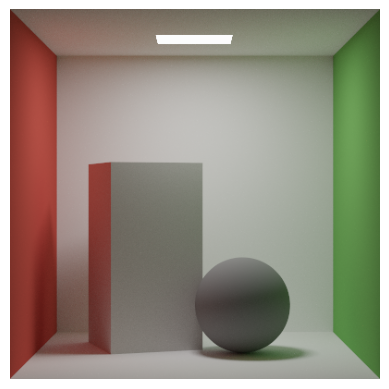

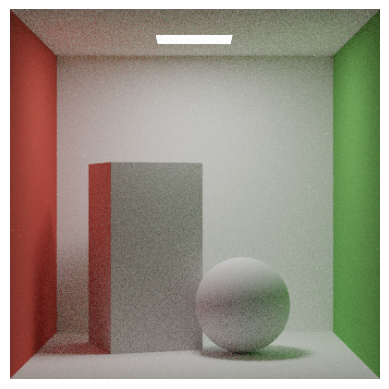

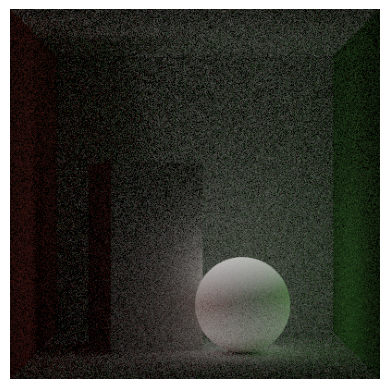

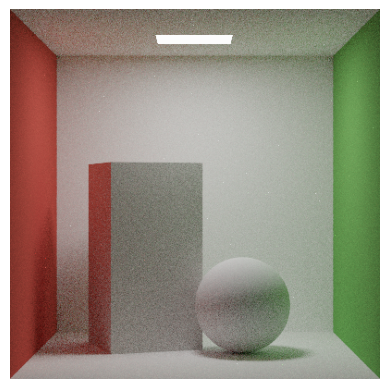

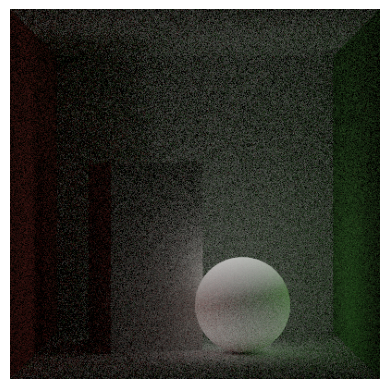

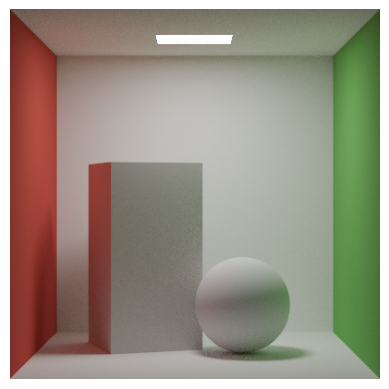

In [41]:
def tone_mapping(hdr_image, gamma=2.2):
    # Apply simple tone mapping and gamma correction.
    ldr_image = hdr_image / (1.0 + hdr_image)
    ldr_image = np.power(ldr_image, 1.0 / gamma)
    return np.clip(ldr_image, 0, 1)

def show_image(taichi_field, gamma=2.2, tone_map=True):
    # Convert the Taichi field to a NumPy array.
    image_np = taichi_field.to_numpy()
    if np.isnan(image_np).any() or np.isinf(image_np).any():
        print("Warning: NaN or Inf values detected in the image")
    image_np = np.clip(image_np, 0, np.inf)
    # Apply tone mapping if desired.
    if tone_map:
        image_np = tone_mapping(image_np, gamma)
    plt.imshow(image_np)
    plt.axis('off')
    plt.show()

# Usage:
show_image(H0)
show_image(F1_A)
show_image(D_A)
show_image(F1_B)
show_image(D_B)
show_image(F_final)

In [42]:
@ti.kernel
def update_mats():
    # Change the material configurations of left sphere
    ordered_prims[22].material.edited = 1
    # change colour to white
    ordered_prims[22].material.reflectance = vec3([0.800, 0.800, 0.800])
    ordered_prims[22].bsdf.add_diffuse(vec3([0.800, 0.800, 0.800]))

update_mats()

print(ordered_prims[22].bsdf)

# High Quality Edited Scene
H1 = ti.Vector.field(3, ti.f32, shape=(HEIGHT, WIDTH))


start_time = time.time()
# Render high-quality control image H0
print("Rendering Edited Image...")
render_control_image(scene, H1, camera, ordered_prims, linear_bvh, lights)
ti.sync()
time_control_image = time.time() - start_time
print(f"  Time taken: {time.strftime('%M:%S', time.gmtime(time_control_image))}")

{'type': <taichi.lang.field.SNodeHostAccess object at 0x117dcd3d0>, 'diffuse': {'R': [0.800000011920929, 0.800000011920929, 0.800000011920929]}, 'diffuse_transmission': {'R': [0.0, 0.0, 0.0], 'T': [0.0, 0.0, 0.0]}, 'dielectric': {'eta': <taichi.lang.field.SNodeHostAccess object at 0x126419a50>, 'color': [0.0, 0.0, 0.0], 'mf_distrib': {'alpha_x': <taichi.lang.field.SNodeHostAccess object at 0x126418410>, 'alpha_y': <taichi.lang.field.SNodeHostAccess object at 0x12641ab90>}}, 'conductor': {'eta': [0.0, 0.0, 0.0], 'k': [0.0, 0.0, 0.0], 'mf_distrib': {'alpha_x': <taichi.lang.field.SNodeHostAccess object at 0x126419a10>, 'alpha_y': <taichi.lang.field.SNodeHostAccess object at 0x12641b210>}}, 'frame': {'x': [0.0, 0.0, 0.0], 'y': [0.0, 0.0, 0.0], 'z': [0.0, 0.0, 0.0]}}
Rendering Edited Image...
  Time taken: 06:09


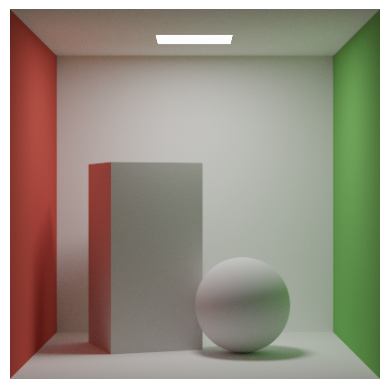

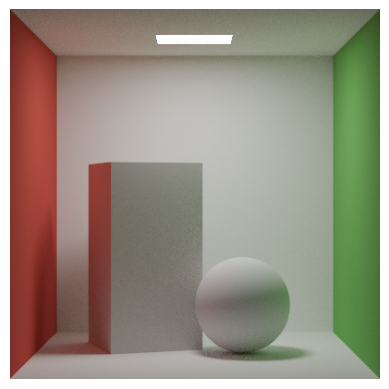

In [43]:
show_image(H1)
show_image(F_final)

In [44]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error

def compute_metrics(taichi_field, reference_field, gamma=2.2, tone_map=True):
    # Convert Taichi fields to NumPy arrays.
    image = taichi_field.to_numpy()
    reference = reference_field.to_numpy()
    
    # Clip to remove any extreme values.
    image = np.clip(image, 0, np.inf)
    reference = np.clip(reference, 0, np.inf)
    
    # Apply tone mapping if desired.
    if tone_map:
        image = tone_mapping(image, gamma)
        reference = tone_mapping(reference, gamma)
    
    # Determine data_range from the images
    data_range = image.max() - image.min()
    
    # Calculate MSE using skimage
    mse_val = mean_squared_error(image, reference)
    
    # Calculate SSIM
    # Choose window size based on image dimensions
    min_dimension = min(min(image.shape[0:2]), min(reference.shape[0:2]))
    win_size = 7
    if min_dimension < 7:
        win_size = min_dimension
        if win_size % 2 == 0:  # Window size must be odd
            win_size -= 1
        if win_size < 3:
            raise ValueError("Images too small for SSIM calculation (minimum dimension: 3)")
    
    ssim_val = ssim(image, reference, win_size=win_size, channel_axis=2, data_range=data_range)
    
    return mse_val, ssim_val

# Example usage:
mse_value, ssim_value = compute_metrics(F_final, H1, gamma=2.2, tone_map=True)
print("MSE:", mse_value)
print("SSIM:", ssim_value)

/Volumes/Work/Projects/Rendering/light-transport-simulator/.conda/lib/python3.11/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/Volumes/Work/Projects/Rendering/light-transport-simulator/.conda/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


MSE: 7.748795311617019e-05
SSIM: 0.9422283


In [45]:
mse_value, ssim_value = compute_metrics(F_final, F1_A, gamma=2.2, tone_map=True)
print("MSE:", mse_value)
print("SSIM:", ssim_value)

MSE: 0.0006766577650842737
SSIM: 0.7265253


In [46]:
def compare_image_metrics(pairA_image, pairA_reference, pairB_image, pairB_reference, gamma=2.2, tone_map=True):
    # Compute metrics for Pair A and Pair B
    mse_A, ssim_A = compute_metrics(pairA_image, pairA_reference, gamma, tone_map)
    mse_B, ssim_B = compute_metrics(pairB_image, pairB_reference, gamma, tone_map)
    
    # Compute percentage difference for MSE (lower is better)
    mse_diff = mse_B - mse_A
    mse_percent_improvement = (mse_diff / mse_B) * 100 if mse_B != 0 else 0
    
    # Compute percentage difference for SSIM (higher is better)
    ssim_diff = ssim_A - ssim_B
    ssim_percent_improvement = (ssim_diff / ssim_B) * 100 if ssim_B != 0 else 0
    
    print("Pair A: MSE = {:.6f}, SSIM = {:.2%}".format(mse_A, ssim_A))
    print("Pair B: MSE = {:.6f}, SSIM = {:.2%}".format(mse_B, ssim_B))
    
    if mse_percent_improvement > 0:
        print("Pair A is {:.2f}% better than Pair B in terms of MSE.".format(mse_percent_improvement))
    else:
        print("Pair A is {:.2f}% worse than Pair B in terms of MSE.".format(-mse_percent_improvement))
        
    if ssim_percent_improvement > 0:
        print("Pair A is {:.2f}% better than Pair B in terms of SSIM.".format(ssim_percent_improvement))
    else:
        print("Pair A is {:.2f}% worse than Pair B in terms of SSIM.".format(-ssim_percent_improvement))

# Example usage:
# Let F_final be the CVPT result and H1 be the result from a standard path tracer.
# Or you could compare two different methods; for instance, pair A uses F_final vs H1 and pair B uses another method.
compare_image_metrics(F_final, H1, F1_A, H1, gamma=2.2, tone_map=True)

Pair A: MSE = 0.000077, SSIM = 94.22%
Pair B: MSE = 0.000713, SSIM = 70.67%
Pair A is 89.13% better than Pair B in terms of MSE.
Pair A is 33.33% better than Pair B in terms of SSIM.


/var/folders/wh/k56cqfld3sb6mcx2fr_1w3rm0000gn/T/ipykernel_20235/3912323482.py:4: RuntimeWarning: invalid value encountered in power
  ldr_image = np.power(ldr_image, 1.0 / gamma)


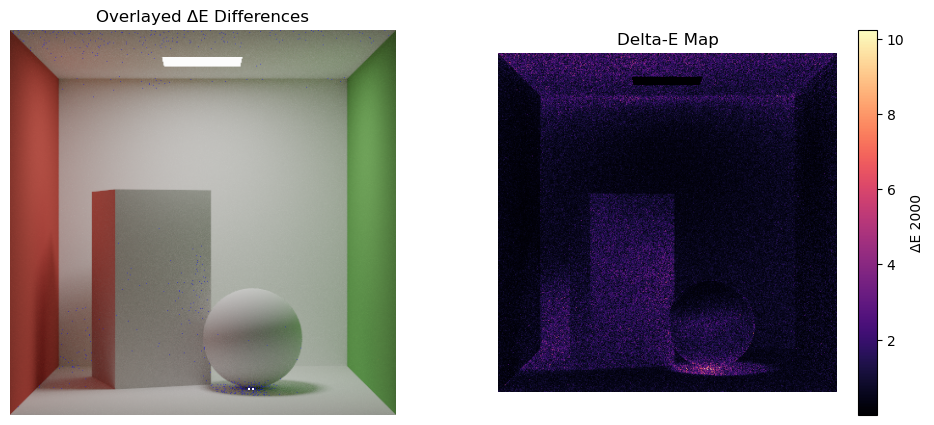

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, deltaE_ciede2000

def compute_deltaE_map(img1, img2):
    """
    Computes a delta-E map between two images in Lab color space.
    Both images must be in [0,1] float range, shape (H, W, 3).
    """
    # Convert both images to Lab color space
    lab1 = rgb2lab(img1)
    lab2 = rgb2lab(img2)
    
    # Compute delta-E using the CIEDE2000 formula
    delta_e_map = deltaE_ciede2000(lab1, lab2)
    return delta_e_map

def overlay_deltaE(img1, img2, threshold=2.0, color=[1,0,0], alpha=0.5):
    """
    Overlays 'color' wherever the delta-E exceeds a certain threshold.
    Returns an overlay image and the delta-E map.
    """
    delta_e_map = compute_deltaE_map(img1, img2)
    # Create a mask where delta-E is above threshold
    mask = delta_e_map > threshold
    
    # Create an overlay by blending with the chosen color
    overlay = img1.copy()
    overlay[mask] = (1 - alpha) * overlay[mask] + alpha * np.array(color)
    return overlay, delta_e_map

# Example usage:
# Assume final_img and ref_img are your images as NumPy arrays in [0,1].
overlay_img, delta_e_map = overlay_deltaE(tone_mapping(F_final.to_numpy()), tone_mapping(H1.to_numpy()), threshold=4, color=[0,0,1], alpha=0.4)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(overlay_img)
plt.title("Overlayed ΔE Differences")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(delta_e_map, cmap='magma')
plt.colorbar(label="ΔE 2000")
plt.title("Delta-E Map")
plt.axis('off')
plt.show()